# Análise dos Microdados do ENEM (2020–2023)

Este notebook consolida o **pipeline ETL** e as **análises exploratórias** dos microdados do ENEM. O processamento é feito inteiramente em memória com PySpark — as tabelas dimensionais e a tabela fato são construídas a partir dos arquivos brutos e ficam disponíveis como DataFrames Spark para as análises.

**Etapas:**
1. Configuração do ambiente e constantes de mapeamento
2. Construção das dimensões de suporte (tempo e renda)
3. Carregamento e transformação dos microdados brutos
4. Construção das tabelas dimensionais (DIM_CANDIDATO, DIM_ESCOLA, DIM_LOCALIDADE)
5. Construção da tabela fato (FATO_DESEMPENHO)
6. Análises exploratórias com visualizações

## 1. Configuração do Ambiente

Importações, inicialização do SparkSession e definição de todas as constantes de mapeamento utilizadas no pipeline: dicionários de raça/cor, renda familiar, sexo, tipo de escola, etc.

A sessão Spark é configurada com `local[*,4]` (usa todos os núcleos da máquina, com máximo de 4 threads de fallback) e 6 GB de memória para o driver.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from functools import reduce
from itertools import chain
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

PASTA_DADOS = "MICRODADOS_ENEM"
ANOS = [2020, 2021, 2022, 2023]

COLUNAS = [
    "NU_ANO",
    "TP_FAIXA_ETARIA", "TP_SEXO", "TP_COR_RACA",
    "TP_ST_CONCLUSAO", "TP_ANO_CONCLUIU", "IN_TREINEIRO",
    "TP_ESCOLA", "TP_DEPENDENCIA_ADM_ESC", "TP_LOCALIZACAO_ESC",
    "CO_MUNICIPIO_PROVA", "NO_MUNICIPIO_PROVA", "SG_UF_PROVA",
    "TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT",
    "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT",
    "NU_NOTA_COMP1", "NU_NOTA_COMP2", "NU_NOTA_COMP3",
    "NU_NOTA_COMP4", "NU_NOTA_COMP5", "NU_NOTA_REDACAO",
    "TP_STATUS_REDACAO", "Q006",
]

# O questionário do ENEM usa O, P e Q para a mesma faixa "Acima de R$ 19.800"
# (códigos variaram entre edições). ORDEM_RENDA define as 15 faixas distintas;
# RENDA_MAP consolida P e Q no mesmo SK de O para não triplicar a categoria.
ORDEM_RENDA = list("ABCDEFGHIJKLMNO")
MAP_RENDA = {
    "A": "Nenhuma renda",      "B": "Até R$ 1.320",     "C": "R$ 1.320–1.980",
    "D": "R$ 1.980–2.640",     "E": "R$ 2.640–3.300",   "F": "R$ 3.300–3.960",
    "G": "R$ 3.960–5.280",     "H": "R$ 5.280–6.600",   "I": "R$ 6.600–7.920",
    "J": "R$ 7.920–9.240",     "K": "R$ 9.240–10.560",  "L": "R$ 10.560–11.880",
    "M": "R$ 11.880–13.200",   "N": "R$ 13.200–19.800", "O": "Acima de R$ 19.800",
}
RENDA_MAP = {letra: i + 1 for i, letra in enumerate(ORDEM_RENDA)}
RENDA_MAP["P"] = RENDA_MAP["O"]
RENDA_MAP["Q"] = RENDA_MAP["O"]

MAP_COR_RACA = {0: "Não declarado", 1: "Branca", 2: "Preta", 3: "Parda", 4: "Amarela", 5: "Indígena"}
MAP_SEXO     = {"M": "Masculino", "F": "Feminino"}
MAP_DEP_ADM  = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}
MAP_LOCALIZ  = {1: "Urbana", 2: "Rural"}
TEMPO_MAP    = {ano: i + 1 for i, ano in enumerate(ANOS)}

spark = (
    SparkSession.builder
    .appName("ENEM_ETL_Analise")
    .master("local[*,4]")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
print(f"Spark {spark.version} — sessão iniciada")

Spark 4.1.2 — sessão iniciada


## 2. Dimensões de Suporte

Criamos as duas dimensões menores diretamente em Python, sem leitura de arquivos:

- **DIM_TEMPO**: um registro por edição do ENEM (2020–2023), com flag indicando se é pós-pandemia (`FL_POS_COVID = 0` apenas para 2020).
- **DIM_RENDA**: 15 faixas de renda familiar derivadas do questionário socioeconômico. As letras P e Q (usadas em algumas edições) são consolidadas na mesma faixa de O ("Acima de R$ 19.800") para não triplicar a categoria.

In [2]:
tempo_rows = [
    (i + 1, ano, f"ENEM {ano}", 0 if ano == 2020 else 1)
    for i, ano in enumerate(ANOS)
]
dim_tempo = spark.createDataFrame(
    tempo_rows, ["SK_TEMPO", "NU_ANO", "DS_PERIODO", "FL_POS_COVID"]
)
dim_tempo.show()

renda_rows = [
    (i + 1, letra, MAP_RENDA[letra], i)
    for i, letra in enumerate(ORDEM_RENDA)
]
dim_renda = spark.createDataFrame(
    renda_rows, ["SK_RENDA", "CD_RENDA", "DS_FAIXA_RENDA", "NU_ORDEM_RENDA"]
)
print(f"DIM_RENDA: {dim_renda.count()} registros")

+--------+------+----------+------------+
|SK_TEMPO|NU_ANO|DS_PERIODO|FL_POS_COVID|
+--------+------+----------+------------+
|       1|  2020| ENEM 2020|           0|
|       2|  2021| ENEM 2021|           1|
|       3|  2022| ENEM 2022|           1|
|       4|  2023| ENEM 2023|           1|
+--------+------+----------+------------+

DIM_RENDA: 15 registros


## 3. Carregamento e Transformação dos Microdados Brutos

Os microdados de cada ano são lidos individualmente (formato Parquet) e empilhados via `union`. Em seguida, aplicamos as seguintes transformações:

- **Cast de notas** para `float`
- **Nullificação de notas objetivas** para candidatos ausentes (`TP_PRESENCA_* != 1`)
- **Nullificação de notas de redação** para status inválido (`TP_STATUS_REDACAO != 1`)
- **Flags de presença**: `FL_AUSENTE_TOTAL` (faltou a tudo) e `FL_PRESENTE_ALGUMA`
- **Cálculo de médias**: média das 4 provas objetivas e média geral (objetivas + redação)
- **Mapeamentos**: renda Q006 → SK_RENDA, raça/cor, sexo, dependência administrativa, localização
- **Segmentação**: Treineiro / Egresso / Concluinte / Cursando com base em `IN_TREINEIRO` e `TP_ST_CONCLUSAO`
- **Tipo de escola**: Pública ou Privada, derivado de `TP_ESCOLA` e `TP_DEPENDENCIA_ADM_ESC`

O DataFrame resultante é colocado em cache para evitar releituras nas etapas seguintes.

In [3]:
dfs = [
    spark.read.parquet(f"{PASTA_DADOS}/MICRODADOS_ENEM_{ano}.parquet").select(COLUNAS)
    for ano in ANOS
]
df = reduce(lambda a, b: a.union(b), dfs)

# Cast notas para float
NOTAS = [
    "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT",
    "NU_NOTA_COMP1", "NU_NOTA_COMP2", "NU_NOTA_COMP3",
    "NU_NOTA_COMP4", "NU_NOTA_COMP5", "NU_NOTA_REDACAO",
]
for c in NOTAS:
    df = df.withColumn(c, F.col(c).cast("float"))

# Notas objetivas → null se candidato ausente
for nota, pres in [
    ("NU_NOTA_CN", "TP_PRESENCA_CN"), ("NU_NOTA_CH", "TP_PRESENCA_CH"),
    ("NU_NOTA_LC", "TP_PRESENCA_LC"), ("NU_NOTA_MT", "TP_PRESENCA_MT"),
]:
    df = df.withColumn(nota, F.when(F.col(pres) == 1, F.col(nota)))

# Notas de redação → null se status != 1
for c in ["NU_NOTA_COMP1", "NU_NOTA_COMP2", "NU_NOTA_COMP3",
          "NU_NOTA_COMP4", "NU_NOTA_COMP5", "NU_NOTA_REDACAO"]:
    df = df.withColumn(c, F.when(F.col("TP_STATUS_REDACAO") == 1, F.col(c)))

# Flags de presença
df = (df
    .withColumn("FL_AUSENTE_TOTAL",
        ((F.col("TP_PRESENCA_CN") == 0) & (F.col("TP_PRESENCA_CH") == 0) &
         (F.col("TP_PRESENCA_LC") == 0) & (F.col("TP_PRESENCA_MT") == 0)).cast("int"))
    .withColumn("FL_PRESENTE_ALGUMA",
        ((F.col("TP_PRESENCA_CN") == 1) | (F.col("TP_PRESENCA_CH") == 1) |
         (F.col("TP_PRESENCA_LC") == 1) | (F.col("TP_PRESENCA_MT") == 1)).cast("int"))
)

# Médias rowwise
NOTAS_OBJ = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
NOTAS_ALL = NOTAS_OBJ + ["NU_NOTA_REDACAO"]

n_nn     = reduce(lambda a, b: a + b,
                  [F.when(F.col(c).isNotNull(), F.lit(1)).otherwise(F.lit(0)) for c in NOTAS_OBJ])
soma_obj = reduce(lambda a, b: a + b, [F.coalesce(F.col(c), F.lit(0.0)) for c in NOTAS_OBJ])
df = df.withColumn("NU_NOTA_OBJ_MEDIA",
    F.when(n_nn > 0, (soma_obj / n_nn).cast("float")))

all_nn   = reduce(lambda a, b: a & b, [F.col(c).isNotNull() for c in NOTAS_ALL])
soma_all = reduce(lambda a, b: a + b, [F.col(c) for c in NOTAS_ALL])
df = df.withColumn("NU_NOTA_MEDIA",
    F.when(all_nn, (soma_all / len(NOTAS_ALL)).cast("float")))

# Mapeamentos via create_map
def _cmap(d):
    return F.create_map([F.lit(x) for x in chain(*d.items())])

df = (df
    .withColumn("SK_TEMPO",    _cmap(TEMPO_MAP)[F.col("NU_ANO")])
    .withColumn("SK_RENDA",    F.coalesce(_cmap(RENDA_MAP)[F.col("Q006")], F.lit(0)).cast("int"))
    .withColumn("DS_COR_RACA", _cmap(MAP_COR_RACA)[F.col("TP_COR_RACA").cast("int")])
    .withColumn("DS_SEXO",     _cmap(MAP_SEXO)[F.col("TP_SEXO")])
    .withColumn("DS_DEP_ADM",  _cmap(MAP_DEP_ADM)[F.col("TP_DEPENDENCIA_ADM_ESC").cast("int")])
    .withColumn("DS_LOCALIZ",  _cmap(MAP_LOCALIZ)[F.col("TP_LOCALIZACAO_ESC").cast("int")])
)

df = df.withColumn("DS_SEGMENTO",
    F.when(F.col("IN_TREINEIRO") == 1,      "Treineiro")
     .when(F.col("TP_ST_CONCLUSAO") == 1,   "Egresso")
     .when(F.col("TP_ST_CONCLUSAO") == 2,   "Concluinte")
     .when(F.col("TP_ST_CONCLUSAO") == 3,   "Cursando (futuro)")
     .otherwise("Sem EM / Não informado"))

df = df.withColumn("DS_TIPO_ESCOLA",
    F.when(F.col("TP_ESCOLA") == 2, "Pública")
     .when(F.col("TP_ESCOLA") == 3, "Privada")
     .when(F.col("TP_ESCOLA").isin(0, 1, 4) & F.col("TP_DEPENDENCIA_ADM_ESC").isin(1, 2, 3), "Pública")
     .when(F.col("TP_ESCOLA").isin(0, 1, 4) & (F.col("TP_DEPENDENCIA_ADM_ESC") == 4), "Privada")
     .otherwise("Não respondeu"))

df = df.cache()
print("Dados carregados e transformações aplicadas — DataFrame em cache")

Dados carregados e transformações aplicadas — DataFrame em cache


## 4. Construção das Tabelas Dimensionais

Cada dimensão representa um **tipo de entidade** do domínio analítico. As três dimensões derivadas dos microdados são:

- **DIM_CANDIDATO** — perfil demográfico e de segmentação do candidato. `NU_INSCRICAO` foi **removido intencionalmente**: ele identifica um indivíduo específico, não um perfil. Sem ele, a dimensão passa de ~16 milhões de linhas (uma por inscrição) para algumas centenas de combinações únicas de (sexo × raça/cor × faixa etária × segmento), tornando os joins com a fato dramaticamente mais leves. Todas as consultas atuais usam apenas atributos de perfil (`DS_SEGMENTO`, `DS_COR_RACA`), portanto **nenhuma análise é prejudicada**.
- **DIM_ESCOLA** — combinações únicas de tipo, dependência administrativa e localização de escola
- **DIM_LOCALIDADE** — municípios únicos de realização da prova

In [ ]:
# DIM_CANDIDATO — perfil de candidato
CAND_PERFIL = [
    "TP_SEXO", "DS_SEXO",
    "TP_COR_RACA", "DS_COR_RACA",
    "TP_FAIXA_ETARIA",
    "IN_TREINEIRO",
    "TP_ST_CONCLUSAO",
    "DS_SEGMENTO",
]
w_cand = Window.orderBy(*CAND_PERFIL)
dim_candidato = (
    df.select(CAND_PERFIL).dropDuplicates()
    .withColumn("SK_CANDIDATO", F.row_number().over(w_cand))
    .cache()
)
print(f"DIM_CANDIDATO: {dim_candidato.count()} registros")

# DIM_ESCOLA
ESC_COLS = ["TP_ESCOLA", "TP_DEPENDENCIA_ADM_ESC", "TP_LOCALIZACAO_ESC",
            "DS_TIPO_ESCOLA", "DS_DEP_ADM", "DS_LOCALIZ"]
w_esc = Window.orderBy("TP_ESCOLA", "TP_DEPENDENCIA_ADM_ESC", "TP_LOCALIZACAO_ESC")
dim_escola = (
    df.select(ESC_COLS).dropDuplicates()
    .withColumn("SK_ESCOLA", F.row_number().over(w_esc))
    .cache()
)
print(f"DIM_ESCOLA: {dim_escola.count()} registros")

# DIM_LOCALIDADE
LOC_COLS = ["CO_MUNICIPIO_PROVA", "NO_MUNICIPIO_PROVA", "SG_UF_PROVA"]
w_loc = Window.orderBy("SG_UF_PROVA", "NO_MUNICIPIO_PROVA", "CO_MUNICIPIO_PROVA")
dim_localidade = (
    df.select(LOC_COLS).dropDuplicates()
    .withColumn("SK_LOCALIDADE", F.row_number().over(w_loc))
    .cache()
)
print(f"DIM_LOCALIDADE: {dim_localidade.count():,} registros")

DIM_CANDIDATO: 930 perfis únicos
DIM_ESCOLA: 20 registros
DIM_LOCALIDADE: 1,751 registros


## 5. Construção da Tabela Fato

A tabela fato é montada unindo `df` às três dimensões derivadas para resolver as chaves substitutas. O join com `DIM_CANDIDATO` agora usa `CAND_PERFIL` (atributos do perfil) como chave — não mais `NU_INSCRICAO` — o que é suficiente para atribuir o `SK_CANDIDATO` correto a cada linha.

Após o cache da fato, `df` é removido do cache para liberar memória do driver. Os aliases `fato` e `dim_cand` são criados para facilitar a leitura das células de análise.

In [5]:
# Resolver SKs: cada linha de df recebe SK_CANDIDATO pelo perfil, SK_ESCOLA e SK_LOCALIDADE
fato_base = (
    df
    .join(dim_candidato.select(CAND_PERFIL + ["SK_CANDIDATO"]), on=CAND_PERFIL)
    .join(dim_escola.select(ESC_COLS + ["SK_ESCOLA"]), on=ESC_COLS)
    .join(dim_localidade.select(LOC_COLS + ["SK_LOCALIDADE"]), on=LOC_COLS)
)

FATO_COLS = [
    "SK_CANDIDATO", "SK_TEMPO", "SK_ESCOLA", "SK_LOCALIDADE", "SK_RENDA",
    "TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT",
    "FL_AUSENTE_TOTAL", "FL_PRESENTE_ALGUMA",
    "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT",
    "NU_NOTA_COMP1", "NU_NOTA_COMP2", "NU_NOTA_COMP3",
    "NU_NOTA_COMP4", "NU_NOTA_COMP5", "NU_NOTA_REDACAO",
    "TP_STATUS_REDACAO", "NU_NOTA_OBJ_MEDIA", "NU_NOTA_MEDIA",
]
fato_desempenho = fato_base.select(FATO_COLS).cache()
print(f"FATO_DESEMPENHO: {fato_desempenho.count():,} linhas x {len(FATO_COLS)} colunas")
print(f"DIM_RENDA: {len(renda_rows)} registros")
print(f"DIM_TEMPO: {len(tempo_rows)} registros")

df.unpersist()

fato     = fato_desempenho
dim_cand = dim_candidato

FATO_DESEMPENHO: 3,628,825 linhas x 24 colunas
DIM_RENDA: 15 registros
DIM_TEMPO: 4 registros


## 6. Análises Exploratórias

As análises a seguir utilizam diretamente os DataFrames Spark construídos nas etapas anteriores. Cada análise agrega os dados via Spark e converte para Pandas apenas o resultado final (compacto) antes de plotar com Matplotlib/Seaborn.

### 6.1 Taxa de Abstenção por Ano

Mede a proporção de candidatos que faltaram a **todas** as provas objetivas em cada edição. O flag `FL_AUSENTE_TOTAL` foi calculado durante o ETL como 1 quando todas as quatro presenças (`TP_PRESENCA_*`) são iguais a 0.

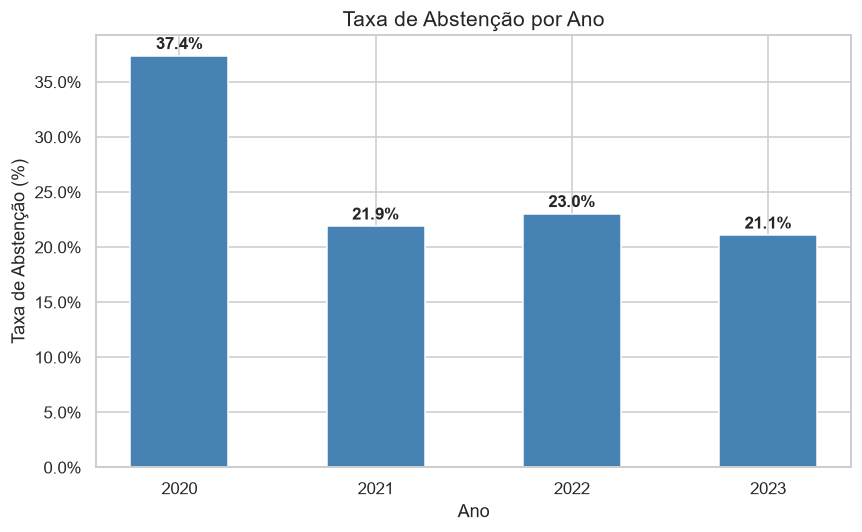

In [6]:
abs_ano = (
    fato
    .join(dim_tempo.select("SK_TEMPO", "NU_ANO"), on="SK_TEMPO")
    .groupBy("NU_ANO")
    .agg(
        F.count("SK_CANDIDATO").alias("total"),
        F.sum("FL_AUSENTE_TOTAL").alias("ausentes"),
    )
    .withColumn("taxa_pct", F.col("ausentes") / F.col("total") * 100)
    .orderBy("NU_ANO")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(abs_ano["NU_ANO"].astype(str), abs_ano["taxa_pct"],
              color="steelblue", width=0.5)
for bar, val in zip(bars, abs_ano["taxa_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Taxa de Abstenção por Ano", fontsize=14)
ax.set_xlabel("Ano")
ax.set_ylabel("Taxa de Abstenção (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

### 6.2 Gap de Desempenho: Escola Pública vs Privada

Compara a nota média de candidatos de escola pública e privada em cada área do conhecimento ao longo dos anos. O tipo de escola (`DS_TIPO_ESCOLA`) foi derivado no ETL a partir de `TP_ESCOLA` e `TP_DEPENDENCIA_ADM_ESC`.

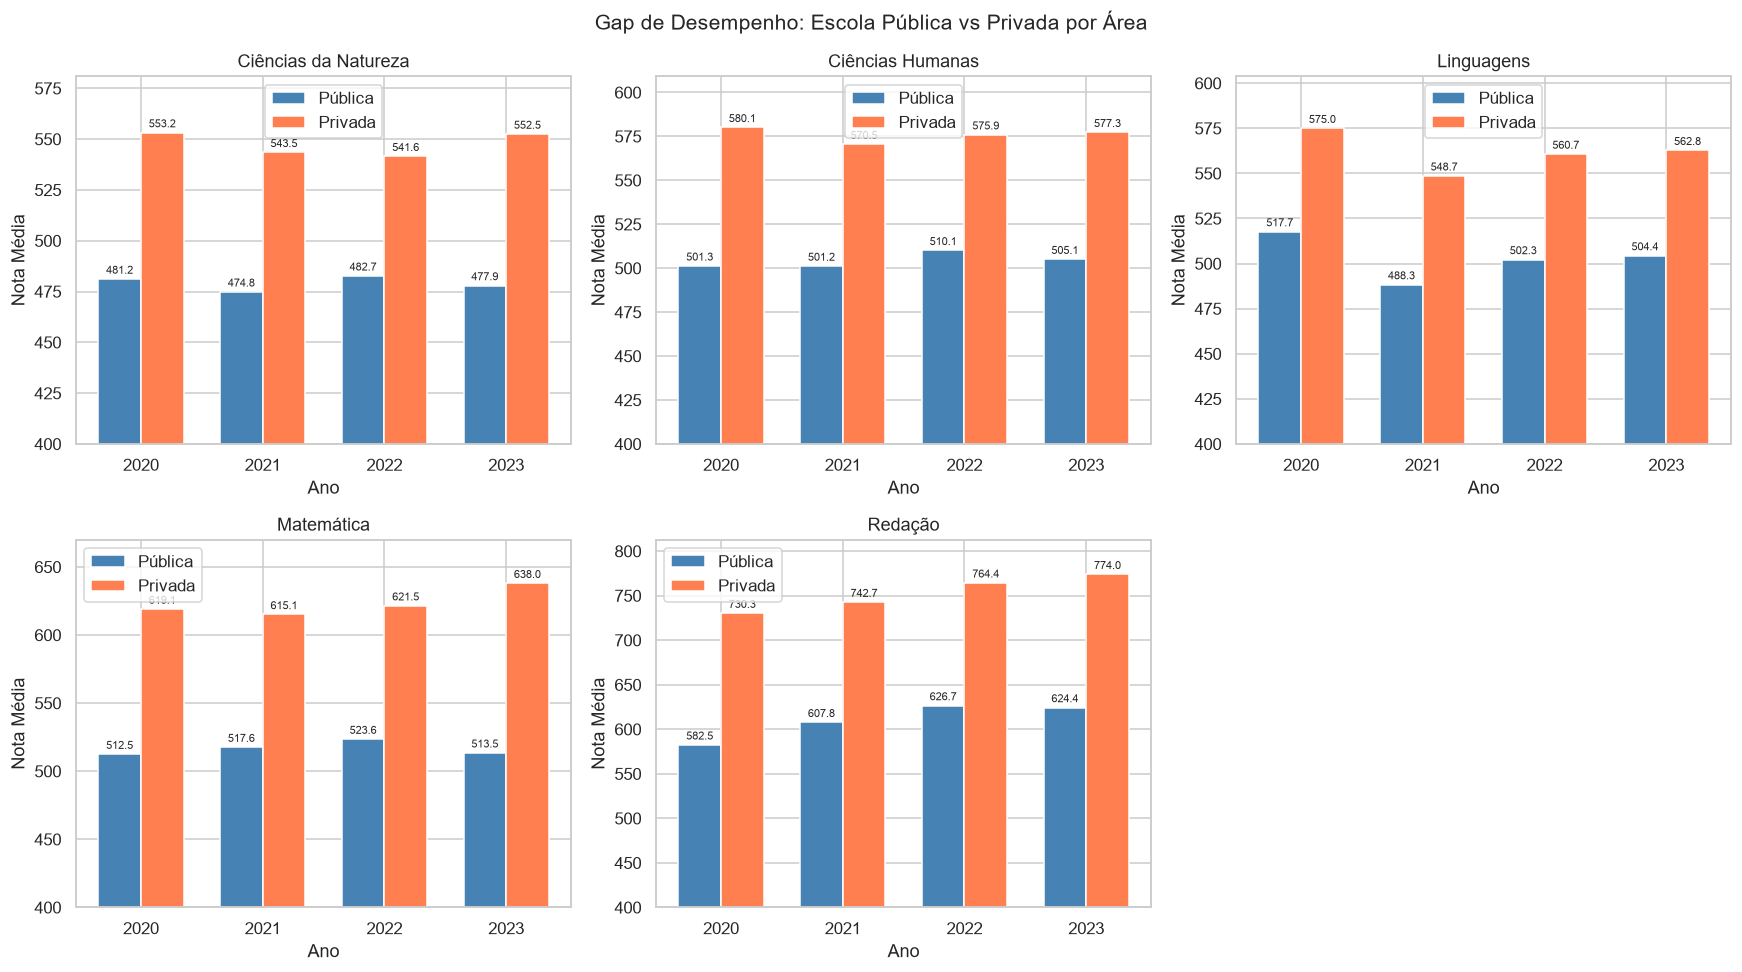

In [7]:
AREAS = {
    "Ciências da Natureza": "NU_NOTA_CN",
    "Ciências Humanas"    : "NU_NOTA_CH",
    "Linguagens"          : "NU_NOTA_LC",
    "Matemática"          : "NU_NOTA_MT",
    "Redação"             : "NU_NOTA_REDACAO",
}
CORES_ESCOLA = {"Pública": "steelblue", "Privada": "coral"}
TIPOS = ["Pública", "Privada"]

gap = (
    fato
    .join(dim_escola.select("SK_ESCOLA", "DS_TIPO_ESCOLA"), on="SK_ESCOLA")
    .join(dim_tempo.select("SK_TEMPO", "NU_ANO"), on="SK_TEMPO")
    .filter(F.col("DS_TIPO_ESCOLA").isin(TIPOS))
    .groupBy("NU_ANO", "DS_TIPO_ESCOLA")
    .agg(*[F.avg(c).alias(c) for c in AREAS.values()])
    .orderBy("NU_ANO", "DS_TIPO_ESCOLA")
    .toPandas()
)

anos  = sorted(gap["NU_ANO"].unique())
x     = np.arange(len(anos))
bar_w = 0.35

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (titulo, col) in enumerate(AREAS.items()):
    ax = axes[i]
    for j, tipo in enumerate(TIPOS):
        sub  = gap[gap["DS_TIPO_ESCOLA"] == tipo].set_index("NU_ANO")
        vals = [sub.loc[a, col] if a in sub.index else 0 for a in anos]
        bars = ax.bar(x + (j - 0.5) * bar_w, vals, bar_w, label=tipo, color=CORES_ESCOLA[tipo])
        for bar, v in zip(bars, vals):
            ax.annotate(f"{v:.1f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + v),
                        xytext=(0, 2), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Nota Média")
    ax.set_xticks(x)
    ax.set_xticklabels(anos)
    ax.set_ylim(bottom=400)
    ax.legend()

axes[-1].set_visible(False)
fig.suptitle("Gap de Desempenho: Escola Pública vs Privada por Área", fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 Desempenho por Segmento: Treineiros, Concluintes e Egressos

Compara o desempenho médio de três perfis de candidatos:

- **Treineiro**: ainda cursando o Ensino Médio, fazendo a prova sem intenção imediata de usar a nota
- **Concluinte**: concluindo o EM no próprio ano da prova
- **Egresso**: já concluiu o EM em anos anteriores

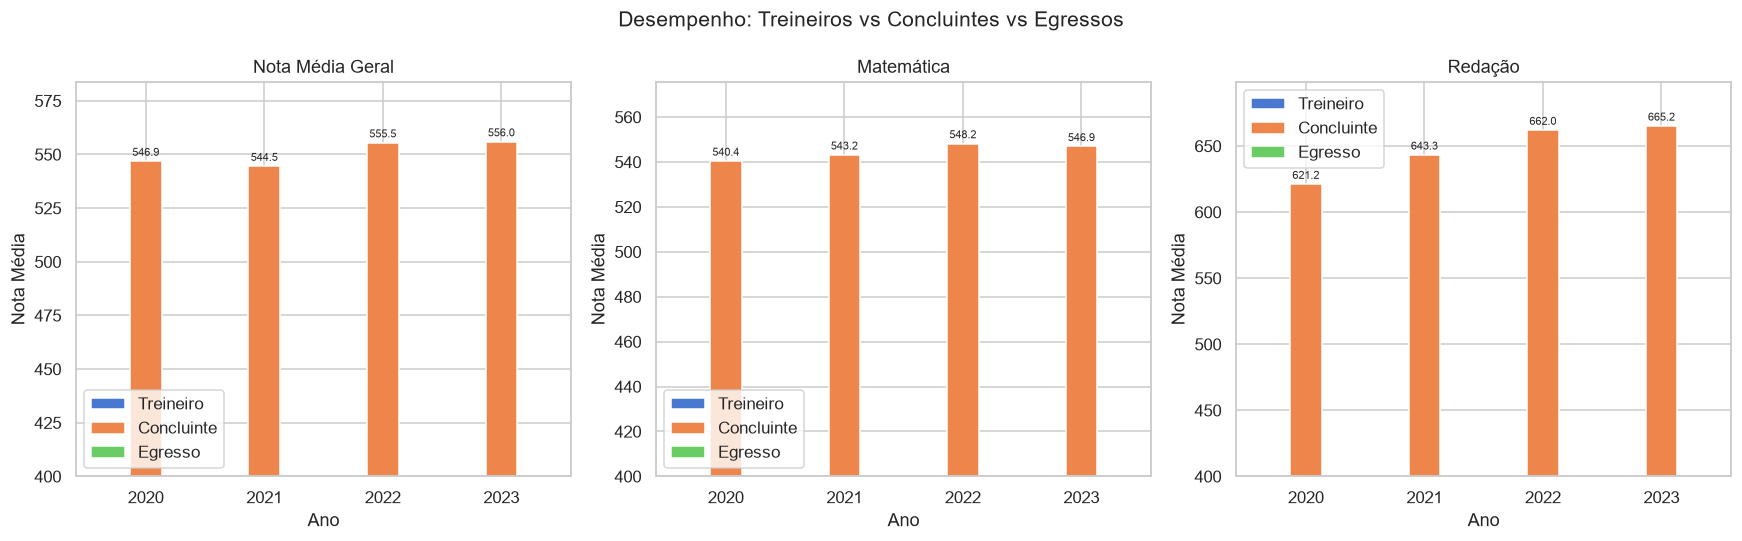

In [8]:
SEGMENTOS = ["Treineiro", "Concluinte", "Egresso"]
METRICAS  = {
    "Nota Média Geral": "NU_NOTA_MEDIA",
    "Matemática"      : "NU_NOTA_MT",
    "Redação"         : "NU_NOTA_REDACAO",
}
CORES_SEG = sns.color_palette("muted", len(SEGMENTOS))

seg = (
    fato
    .join(dim_cand.select("SK_CANDIDATO", "DS_SEGMENTO"), on="SK_CANDIDATO")
    .join(dim_tempo.select("SK_TEMPO", "NU_ANO"), on="SK_TEMPO")
    .filter(F.col("DS_SEGMENTO").isin(SEGMENTOS))
    .groupBy("NU_ANO", "DS_SEGMENTO")
    .agg(*[F.avg(c).alias(c) for c in METRICAS.values()])
    .orderBy("NU_ANO", "DS_SEGMENTO")
    .toPandas()
)

anos  = sorted(seg["NU_ANO"].unique())
x     = np.arange(len(anos))
bar_w = 0.8 / len(SEGMENTOS)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (titulo, col) in zip(axes, METRICAS.items()):
    for j, nome_seg in enumerate(SEGMENTOS):
        sub    = seg[seg["DS_SEGMENTO"] == nome_seg].set_index("NU_ANO")
        vals   = [sub.loc[a, col] if a in sub.index else 0 for a in anos]
        offset = (j - (len(SEGMENTOS) - 1) / 2) * bar_w
        bars   = ax.bar(x + offset, vals, bar_w, label=nome_seg, color=CORES_SEG[j])
        for bar, v in zip(bars, vals):
            ax.annotate(f"{v:.1f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + v),
                        xytext=(0, 2), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Nota Média")
    ax.set_xticks(x)
    ax.set_xticklabels(anos)
    ax.set_ylim(bottom=400)
    ax.legend()

fig.suptitle("Desempenho: Treineiros vs Concluintes vs Egressos", fontsize=14)
plt.tight_layout()
plt.show()

### 6.4 Evolução do Perfil Racial dos Inscritos e Resultados

Dois painéis lado a lado:

- **Esquerda**: número de inscritos por cor/raça e ano
- **Direita**: nota média geral por cor/raça e ano

Candidatos que não declararam raça (`Não declarado`) são excluídos para focar nos grupos autoidentificados.

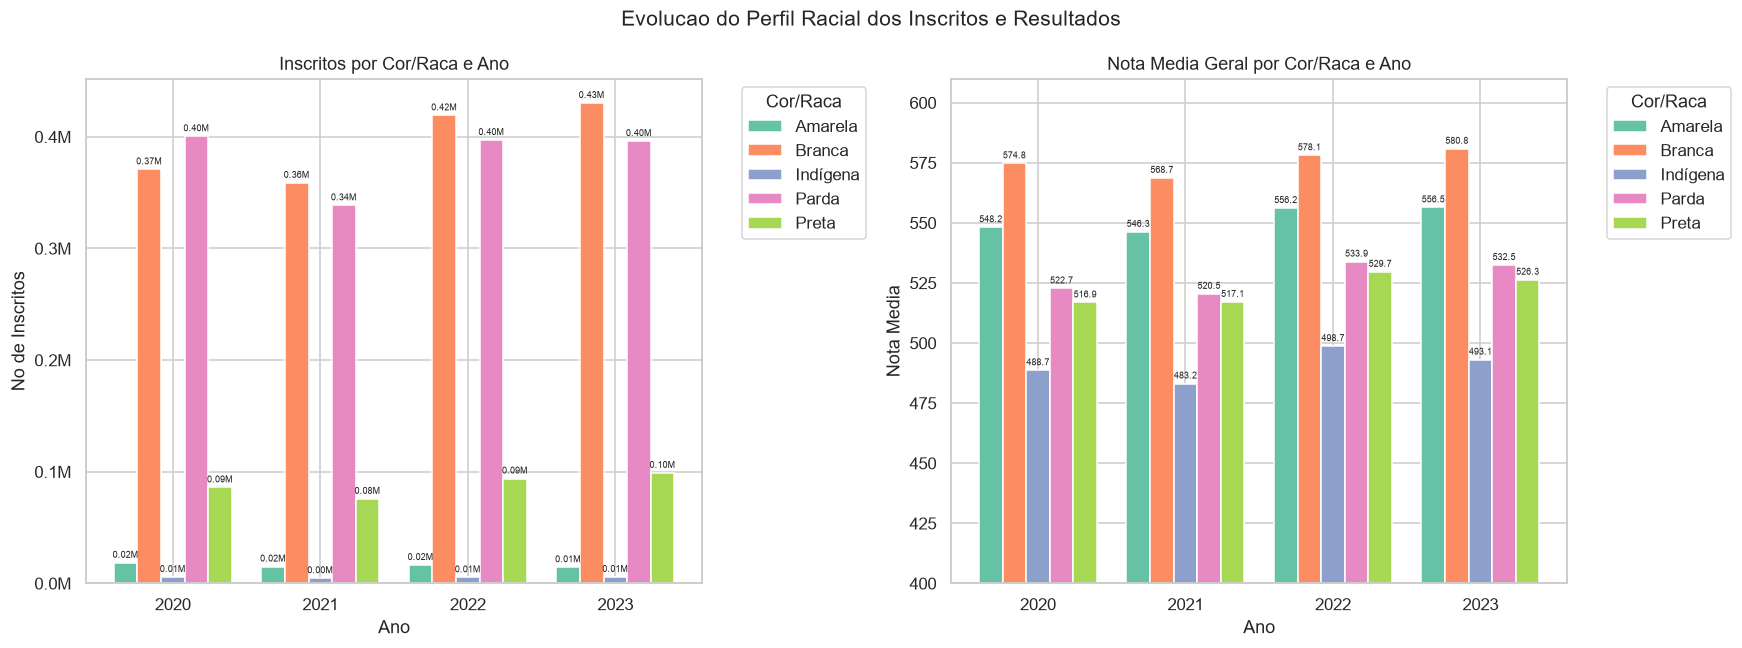

In [9]:
racial = (
    fato
    .join(dim_cand.select("SK_CANDIDATO", "DS_COR_RACA"), on="SK_CANDIDATO")
    .join(dim_tempo.select("SK_TEMPO", "NU_ANO"), on="SK_TEMPO")
    .filter(F.col("DS_COR_RACA").isNotNull() & (F.col("DS_COR_RACA") != "Não declarado"))
    .groupBy("NU_ANO", "DS_COR_RACA")
    .agg(
        F.count("SK_CANDIDATO").alias("inscritos"),
        F.avg("NU_NOTA_MEDIA").alias("media_geral"),
    )
    .orderBy("NU_ANO", "DS_COR_RACA")
    .toPandas()
)

racas  = sorted(racial["DS_COR_RACA"].unique())
anos   = sorted(racial["NU_ANO"].unique())
x      = np.arange(len(anos))
bar_w  = 0.8 / len(racas)
cores  = sns.color_palette("Set2", len(racas))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for j, raca in enumerate(racas):
    sub    = racial[racial["DS_COR_RACA"] == raca].set_index("NU_ANO")
    v_ins  = [sub.loc[a, "inscritos"]   if a in sub.index else 0 for a in anos]
    v_med  = [sub.loc[a, "media_geral"] if a in sub.index else 0 for a in anos]
    offset = (j - (len(racas) - 1) / 2) * bar_w
    bars1  = ax1.bar(x + offset, v_ins, bar_w, label=raca, color=cores[j])
    bars2  = ax2.bar(x + offset, v_med, bar_w, label=raca, color=cores[j])
    for bar, v in zip(bars1, v_ins):
        ax1.annotate(f"{v/1e6:.2f}M",
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + v),
                     xytext=(0, 2), textcoords="offset points",
                     ha="center", va="bottom", fontsize=6)
    for bar, v in zip(bars2, v_med):
        ax2.annotate(f"{v:.1f}",
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + v),
                     xytext=(0, 2), textcoords="offset points",
                     ha="center", va="bottom", fontsize=6)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(anos)
    ax.set_xlabel("Ano")
    ax.legend(title="Cor/Raca", bbox_to_anchor=(1.05, 1), loc="upper left")

ax1.set_title("Inscritos por Cor/Raca e Ano")
ax1.set_ylabel("No de Inscritos")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax2.set_title("Nota Media Geral por Cor/Raca e Ano")
ax2.set_ylabel("Nota Media")
ax2.set_ylim(bottom=400)

fig.suptitle("Evolucao do Perfil Racial dos Inscritos e Resultados", fontsize=14)
plt.tight_layout()
plt.show()

### 6.5 Impacto da Renda Familiar na Nota Média

Nota média geral por faixa de renda familiar (campo Q006 do questionário socioeconômico), agrupada por ano. As 15 faixas vão de "Nenhuma renda" até "Acima de R$ 19.800" e são ordenadas pela coluna `NU_ORDEM_RENDA` da DIM_RENDA. Candidatos que não informaram renda (`SK_RENDA == 0`) são excluídos.

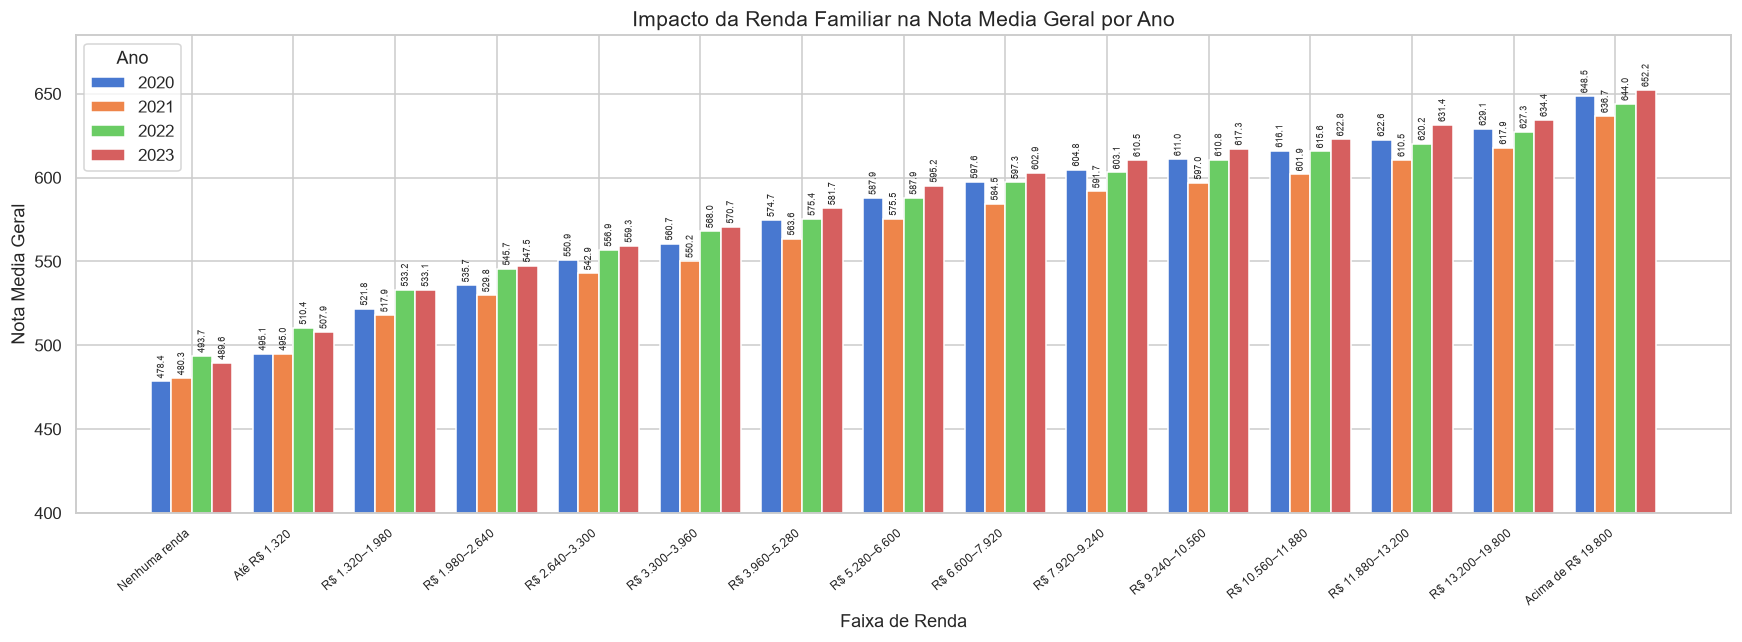

In [10]:
renda = (
    fato
    .join(dim_renda.select("SK_RENDA", "DS_FAIXA_RENDA", "NU_ORDEM_RENDA"), on="SK_RENDA")
    .join(dim_tempo.select("SK_TEMPO", "NU_ANO"), on="SK_TEMPO")
    .filter(F.col("SK_RENDA") > 0)
    .groupBy("NU_ANO", "NU_ORDEM_RENDA", "DS_FAIXA_RENDA")
    .agg(F.avg("NU_NOTA_MEDIA").alias("media_geral"))
    .orderBy("NU_ORDEM_RENDA", "NU_ANO")
    .toPandas()
)

faixas = (renda[["NU_ORDEM_RENDA", "DS_FAIXA_RENDA"]]
          .drop_duplicates().sort_values("NU_ORDEM_RENDA"))
anos   = sorted(renda["NU_ANO"].unique())
x      = np.arange(len(faixas))
bar_w  = 0.8 / len(anos)
cores  = sns.color_palette("muted", len(anos))

fig, ax = plt.subplots(figsize=(16, 6))

for j, ano in enumerate(anos):
    sub  = renda[renda["NU_ANO"] == ano].set_index("NU_ORDEM_RENDA")
    vals = [sub.loc[o, "media_geral"] if o in sub.index else 0
            for o in faixas["NU_ORDEM_RENDA"]]
    offset = (j - (len(anos) - 1) / 2) * bar_w
    bars   = ax.bar(x + offset, vals, bar_w, label=str(ano), color=cores[j])
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.annotate(f"{v:.1f}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + v),
                        xytext=(0, 2), textcoords="offset points",
                        ha="center", va="bottom", fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(faixas["DS_FAIXA_RENDA"], rotation=40, ha="right", fontsize=8)
ax.set_title("Impacto da Renda Familiar na Nota Media Geral por Ano", fontsize=14)
ax.set_xlabel("Faixa de Renda")
ax.set_ylabel("Nota Media Geral")
ax.set_ylim(bottom=400)
ax.legend(title="Ano")
plt.tight_layout()
plt.show()

## Encerramento

Encerra a sessão Spark e libera todos os recursos (memória, threads, JVM).

In [11]:
spark.stop()